In [1]:
import os
import re
import time
import random
import requests
import pandas as pd
import json
import threading
 
from pathlib import Path
from pydantic import BaseModel, Field
from helpers import get_content
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from openai import OpenAI
from typing import List, Dict, Any


df = pd.read_csv('rna_seq_data/rna_seq_gds_with_publication_filtered.csv')
survival_pmcids = set(pd.read_csv('rna_seq_data/survival-analysis-papers.csv')['pmcid'].tolist())

gse_to_pmcid = {}
for _, row in df.iterrows():
    gseid = row['accession']
    pmcids = [pmcid for pmcid in row['pmcids'].split(';') if pmcid in survival_pmcids]
    if pmcids:
        # print(gseid, pmcids)
        gse_to_pmcid[gseid] = pmcids


## vibecoded part
# pmcid_to_accession = {}
# for _, row in df.iterrows():
#     access = row['accession']
#     pmcids = str(row['pmcids'])
#     for pmcid in pmcids.split(';'):
#         pmcid = pmcid.strip()
#         if pmcid:
#             pmcid_to_accession[pmcid] = access
# ## vibecoded part



# gse_to_pmcid = dict([(pmcid_to_accession[pmcid], pmcid) for pmcid in pmcids])


In [2]:
import time
import requests
import pandas as pd


def _parse_series_fields_from_text(text: str):
    title_vals = []
    summary_vals = []
    overall_design_vals = []
    sample_ids = []

    for line in text.splitlines():
        if line.startswith("!Series_title"):
            title_vals.append(line.split("=", 1)[1].strip() if "=" in line else "")
        elif line.startswith("!Series_summary"):
            summary_vals.append(line.split("=", 1)[1].strip() if "=" in line else "")
        elif line.startswith("!Series_overall_design"):
            overall_design_vals.append(line.split("=", 1)[1].strip() if "=" in line else "")
        elif line.startswith("!Series_sample_id"):
            sample_id = line.split("=", 1)[1].strip() if "=" in line else ""
            if sample_id:
                sample_ids.append(sample_id)
        elif line.startswith("^SAMPLE"):  # fallback for some GEO text variants
            sample_id = line.split("=", 1)[1].strip() if "=" in line else ""
            if sample_id:
                sample_ids.append(sample_id)

    title = "\n".join(v for v in title_vals if v) or None
    summary = "\n".join(v for v in summary_vals if v) or None
    overall_design = "\n".join(v for v in overall_design_vals if v) or None
    sample_count = len(set(sample_ids)) if sample_ids else None

    return title, summary, overall_design, sample_count


def fetch_gse_text_summaries(gse_ids, sleep_sec=0.05, timeout=30):
    session = requests.Session()
    rows = []

    for gse in gse_ids:
        gse = str(gse).strip()
        if not gse:
            continue

        params = {
            "acc": gse,
            "targ": "self",
            "form": "text",
            "view": "quick",
        }

        try:
            r = session.get(
                "https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi",
                params=params,
                timeout=timeout,
            )
            r.raise_for_status()

            title, summary, overall_design, sample_count = _parse_series_fields_from_text(r.text)   
            text_summary = "\n\n".join(
                x for x in [title, summary, overall_design] if x
            ) or None

            rows.append(
                {
                    "accession": gse,
                    "title": title,
                    "summary": summary,
                    "overall_design": overall_design,
                    "text_summary": text_summary,
                    "sample_count": sample_count,
                }
            )
        except Exception as e:
            print(f"{gse}: failed ({e})")
            rows.append(
                {
                    "accession": gse,
                    "title": None,
                    "summary": None,
                    "overall_design": None,
                    "text_summary": None,
                    "sample_count": None,
                }
            )

        time.sleep(sleep_sec)

    return pd.DataFrame(rows)
    
meta_df = fetch_gse_text_summaries(list(gse_to_pmcid.keys()))
meta_df.head()

,accession,title,summary,overall_design,text_summary,sample_count
0,GSE270967,LncRNA expression profile is associated with n...,Purpose: Identified the expression profile of ...,Transcriptomic analysis of 47 tumor samples fr...,LncRNA expression profile is associated with n...,20
1,GSE247185,Impact of immune repertoire in Muscle â Inva...,Purpose: Neoadjuvant cisplatin-based Chemother...,To identify preditive biomarkers associated wi...,Impact of immune repertoire in Muscle â Inva...,13
2,GSE241466,Transcriptomic profiling of the intermediate c...,Introduction: Combined hepatocellular-cholangi...,"Trnascriptomic profiling from 7 cases of NT, 5...",Transcriptomic profiling of the intermediate c...,25
3,GSE242786,Molecular differentiation between complete and...,Neoadjuvant chemoradiotherapy (nCRT) is the st...,To investigate the transcriptomic differences ...,Molecular differentiation between complete and...,15
4,GSE226773,Transcriptomic analysis of patient-derived res...,To identify genes encoding cell surface protei...,Comparative gene expression profiling analysis...,Transcriptomic analysis of patient-derived res...,4


In [ ]:
SYSTEM_PROMPT = """You are an expert biomedical data curator. You will receive two texts:
1. GEO dataset metadata
2. Excerpts from a scientific paper

Your task is to determine whether the GEO dataset contains the RNA-seq expression data used for the paper’s survival or prognostic analysis.

CRITICAL CONTEXT:
GEO primarily stores RNA-seq gene expression data. GEO may not contain clinical outcomes. Your job is not to check whether GEO contains survival data. Your job is to determine whether the patients whose expression measurements were used for the paper’s survival or prognostic analysis are represented in the GEO dataset. GEO may contain a superset (e.g., additional controls or different disease stages) or a subset (e.g., only some analyzed patients) of the final survival cohort; this is acceptable only if the text indicates it is the same patient-level expression dataset underlying the survival analysis.

INSTRUCTIONS:
1. Identify the GEO cohort: Determine which subjects were profiled in GEO. Extract cohort-defining details when available, including subject count, disease, sample type, collection timepoint, institution, inclusion criteria, and assay type.
2. Identify the paper cohort used for survival or prognostic analysis: Find the analysis tied to patient outcomes. Determine which expression dataset was used for that analysis and what cohort it represents.
3. Compare the GEO cohort with the paper’s survival/prognostic expression cohort.
4. Prefer explicit statements over inference. If the paper explicitly links the GEO accession to the cohort used in survival/prognostic analysis, that is strong evidence. If the paper indicates GEO was used for a separate discovery, mechanistic, validation, or subgroup analysis while survival/prognostic analysis used another dataset or assay, classify accordingly.

CLASSIFICATION CATEGORIES:
- "SAME COHORT": GEO contains RNA-seq expression profiles for the patients whose expression data were used in the paper’s survival/prognostic analysis. GEO may be a subset or superset of that cohort, but only if it includes the same patient-level expression dataset underlying the survival analysis.
- "DIFFERENT COHORT": The survival/prognostic analysis used expression data from a completely different subject set than the GEO dataset (for example, an external public cohort such as TCGA versus an internal GEO cohort).
- "DIFFERENT ANALYSIS": GEO contains data from subjects in the same study or paper, but it is clear from the text that these specific GEO RNA-seq data were used for an entirely different purpose (for example, cell line experiments, mechanistic work, basic differential expression, or a non-survival subgroup analysis), while the survival/prognostic analysis relied on a different dataset or assay.
- "UNCLEAR": The provided text does not allow a confident determination.

DECISION RULES:
- Do not rely only on matching sample counts.
- Do not classify as "SAME COHORT" merely because GEO and the paper involve the same institution, disease type, publication, or similar enrollment period.
- If GEO is a subset or superset of the survival cohort, classify as "SAME COHORT" only if the text indicates they derive from the same patient-level expression dataset used in the survival analysis.
- Do not classify as "DIFFERENT ANALYSIS" merely because sample counts do not perfectly match.
- Only use "DIFFERENT ANALYSIS" if the text shows that the GEO RNA-seq data were generated for and used in a distinct non-survival context, while the survival/prognostic analysis relied on different data.
- If survival/prognostic analysis was performed on a public external cohort while GEO is an in-house cohort, classify as "DIFFERENT COHORT".
- If the paper uses a different expression platform, different processed dataset, or different biospecimen source than GEO for the survival/prognostic analysis, do not classify as "SAME COHORT" unless the paper explicitly states they are the same patient-level expression measurements.
- If the paper uses one assay for GEO subjects and a different assay for the survival/prognostic cohort, classify as "DIFFERENT ANALYSIS" unless the paper explicitly says the same subjects and same expression measurements were used.
- When evidence is incomplete or ambiguous, choose "UNCLEAR".

EVIDENCE RULES:
- You MUST provide short verbatim quotes:
  1. one/two from GEO metadata
  2. one/two from the paper
- Choose the quotes that best identify:
  - the GEO cohort, and
  - the cohort, dataset, or assay used for the survival/prognostic analysis

OUTPUT REQUIREMENTS:
Return ONLY a JSON object with this exact schema:

```json
{
  "evidence": [
    "[Verbatim quote from GEO metadata]",
    "[Verbatim quote from the paper]"
  ],
  "reasoning": "2-3 sentences explaining why the evidence shows the GEO subjects are or are not the subjects used for the paper’s survival/prognostic analysis.",
  "classification": "SAME COHORT | DIFFERENT COHORT | DIFFERENT ANALYSIS | UNCLEAR"
}"""

In [ ]:
USER_PROMPT = """GEO METADATA:
- Summary: {gse_summary}
- Overall design: {gse_overall_design}
- Sample count: {gse_sample_count}
--------------------------------
{articles}"""

input_prompts = []

for gseid, pmcids in gse_to_pmcid.items():
    row = meta_df.loc[meta_df['accession'] == gseid]
    gse_summary = row['text_summary'].values[0]
    gse_overall_design = row['overall_design'].values[0]
    gse_sample_count = row['sample_count'].values[0]

    articles = []
    for i, pmcid in enumerate(pmcids, start=1):
        content = get_content(f'rna_seq_data/bioCjson_raw/{pmcid}.json.gz')
        research_article = f"\n**ARTICLE {pmcid}**\n\nTITLE:{content['TITLE']}\nABSTRACT:{content['ABSTRACT']}\nCONTENT:{content['CONTENT'] + content['FIG_CAPTIONS'] + content['SUPPL']}"
        articles.append(research_article)

    user_prompt = USER_PROMPT.format(gse_summary=gse_summary, gse_overall_design=gse_overall_design, gse_sample_count=gse_sample_count, articles='\n'.join(articles))

    # Store as a list of messages (standard chat format)
    input_prompts.append({
        "gseid": gseid,
        "pmcids": pmcids,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ]
    })

with open("rna_seq_data/survival-analysis-cohort-match-prompts.jsonl", "w") as f:
    for prompt in input_prompts:
        f.write(json.dumps(prompt) + "\n")

In [4]:
import statistics
import tiktoken

prompts_path = "rna_seq_data/survival-analysis-cohort-match-prompts.jsonl"
enc = tiktoken.get_encoding("o200k_base")

user_token_counts = []

with open(prompts_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)

        user_text = "\n".join(
            str(m.get("content", ""))
            for m in item.get("messages", [])
            if m.get("role") == "user"
        )

        user_token_counts.append(len(enc.encode(user_text)))

total_prompts = len(user_token_counts)
total_user_tokens = sum(user_token_counts)
mean_tokens = statistics.mean(user_token_counts) if user_token_counts else 0
median_tokens = statistics.median(user_token_counts) if user_token_counts else 0

system_prompt_tokens_single = len(enc.encode(SYSTEM_PROMPT))
total_system_tokens = system_prompt_tokens_single * total_prompts

print(f"Tokenizer: {enc.name}")
print(f"Total prompts: {total_prompts}")
print(f"Total user tokens: {total_user_tokens:,}")
print(f"Average user tokens per prompt: {mean_tokens:.2f}")
print(f"Median user tokens per prompt: {median_tokens:.2f}")
print(f"System prompt tokens (single): {system_prompt_tokens_single:,}")
print(f"Total system tokens (reused across all prompts): {total_system_tokens:,}")

Tokenizer: o200k_base
Total prompts: 586
Total user tokens: 7,652,960
Average user tokens per prompt: 13059.66
Median user tokens per prompt: 11299.00
System prompt tokens (single): 1,026
Total system tokens (reused across all prompts): 601,236


In [ ]:
class ClassificationResponse(BaseModel):
    """Structured output schema for cohort match classification."""
    evidence: List[str] = Field(description="2 short verbatim quotes: 1 from GEO metadata, 1 from the paper")
    reasoning: str = Field(description="2-3 sentences explaining why the evidence shows the GEO subjects are or are not the same subjects used for the paper’s survival/prognostic analysis.")
    classification: str = Field(description="SAME COHORT | DIFFERENT COHORT | DIFFERENT ANALYSIS | UNCLEAR")


# OpenAI reads OPENAI_API_KEY from the environment.
client = OpenAI()

def _call_openai(messages: List[Dict[str, Any]]) -> Any:
    # Responses API uses "input" + "input_text" content type
    formatted_messages = []
    for msg in messages:
        formatted_messages.append({
            "role": msg["role"],
            "content": [{"type": "input_text", "text": msg["content"]}],
        })

    # client.responses.parse is the correct method for:
    # - structured output (text_format param)
    # - reasoning effort
    # - input_text content type
    resp = client.responses.parse(
        model="gpt-5-mini-2025-08-07", # gpt-5-nano-2025-08-07 , gpt-5-mini-2025-08-07 gpt-5.4-2026-03-05
        input=formatted_messages,
        text_format=ClassificationResponse,  # Pydantic model for structured output
        reasoning={"effort": "medium"},
        service_tier="flex"
    )

    # Result is accessed via resp.output_parsed, not resp.choices[0]
    return resp.output_parsed, resp.usage


def _call_openrouter(messages: List[Dict[str, Any]]) -> Any:
    # IMPORTANT: Use standard create(), not responses.parse() for OSS models
    resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=messages,
        # To force DeepInfra and ensure consistent pricing:
        extra_body={
            "provider": {
                "order": ["DeepInfra"],
                "allow_fallbacks": False
            },
            # Since we can't use 'text_format', we use 'response_format'
            "response_format": {"type": "json_object"}
        }
    )

    content = resp.choices[0].message.content
    if not isinstance(content, str):
        raise TypeError(f"Expected JSON string content, got {type(content).__name__}")

    content = content.strip()
    if not content:
        raise ValueError("OpenRouter returned empty content")

    parsed = ClassificationResponse.model_validate_json(content)

    usage = resp.usage
    input_tokens = getattr(usage, "input_tokens", None)
    if input_tokens is None:
        input_tokens = getattr(usage, "prompt_tokens", None)

    output_tokens = getattr(usage, "output_tokens", None)
    if output_tokens is None:
        output_tokens = getattr(usage, "completion_tokens", None)

    token_details = getattr(usage, "input_tokens_details", None)
    if token_details is None:
        token_details = getattr(usage, "prompt_tokens_details", None)

    usage_details = {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cached_tokens": getattr(token_details, "cached_tokens", None) if token_details is not None else None,
        "total_tokens": getattr(usage, "total_tokens", None),
    }

    return parsed, usage_details



input_prompts = []
with open("rna_seq_data/survival-analysis-cohort-match-prompts.jsonl", "r") as f:
    for line in f:
        if line.strip():
            input_prompts.append(json.loads(line))

results_file = "rna_seq_data/survival-analysis-cohort-match-results-mini.jsonl"
computed_gseid = set()

if os.path.exists(results_file):
    with open(results_file, "r") as f:
        for line in f:
            if not line.strip():
                continue
            result_data = json.loads(line)
            computed_gseid.add(str(result_data.get("gseid")).strip())

pending_prompts = [
    p for p in input_prompts
    if p.get("gseid") not in computed_gseid
]

# # to recompute total_pmcids
# pending_prompts = [
#     p for p in input_prompts
#     if p.get("gseid") in same_cohort_or_unclear_gseids
# ]

print(f"Found {len(computed_gseid)} already computed submissions")
print(f"Processing {len(pending_prompts)} remaining submissions")

# Optional safety stop: uncomment the next line to inspect prompts before API calls.
# raise Exception("Stop here")

MAX_WORKERS = 4
write_lock = threading.Lock()


def _worker(prompt_data, file_handle):
    gseid = prompt_data["gseid"]
    messages = prompt_data["messages"]

    try:
        parsed, usage = _call_openai(messages)
        # parsed, usage = _call_openrouter(messages)  # For OpenRouter, use this line instead
        usage_data = usage.model_dump() if hasattr(usage, "model_dump") else usage
        result_data = {
            "gseid": gseid,
            "response": parsed.model_dump(),
            "usage": usage_data,
        }

        line = json.dumps(result_data, ensure_ascii=False) + "\n"
        with write_lock:
            file_handle.write(line)
            file_handle.flush()

        return {"ok": True, "gseid": gseid}
    except Exception as e:
        return {"ok": False, "gseid": gseid, "error": str(e)}

results_count = 0
error_count = 0
completed_count = 0

with open(results_file, "a", encoding="utf-8") as out_f:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(_worker, p, out_f) for p in pending_prompts]

        for future in as_completed(futures):
            completed_count += 1
            info = future.result()

            if info["ok"]:
                results_count += 1
                if results_count % 10 == 0:
                    print(f"Processed {results_count} submissions...")
            else:
                error_count += 1
                print(f"Error processing {info['gseid']}: {info['error']}")

print(f"Completed! Processed {results_count} new submissions ({error_count} errors)")

# Save the current run in the format expected by the next notebook.
current_rows = []
with open(results_file, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        item = json.loads(line)
        current_rows.append({
            "gseid": str(item.get("gseid", "")).strip(),
            "classification": (item.get("response") or {}).get("classification"),
        })
current_results_df = pd.DataFrame(current_rows, columns=["gseid", "classification"])
current_results_df = current_results_df.drop_duplicates(subset=["gseid"], keep="last")
selected = current_results_df.loc[current_results_df["classification"] == "SAME COHORT", ["gseid"]]
output_path = "rna_seq_data/gseids-candidates.csv"
selected.to_csv(output_path, index=False)
print(f"Saved {len(selected)} same-cohort GSE IDs to {output_path}")


Found 0 already computed submissions
Processing 60 remaining submissions
Processed 10 submissions...
Processed 20 submissions...
Processed 30 submissions...
Processed 40 submissions...
Processed 50 submissions...
Processed 60 submissions...
Completed! Processed 60 new submissions (0 errors)


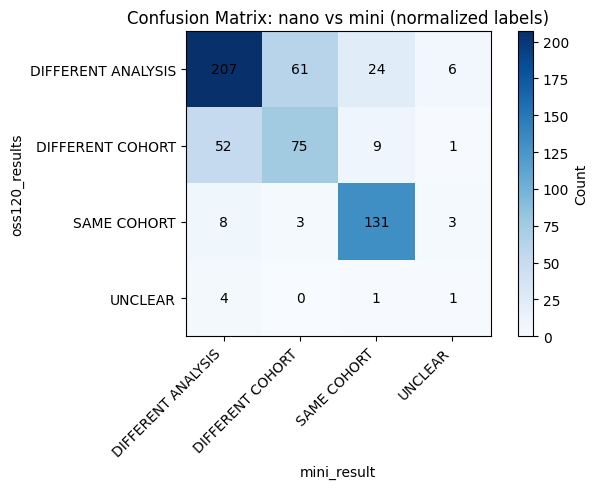

mini_result
DIFFERENT ANALYSIS    271
SAME COHORT           165
DIFFERENT COHORT      139
UNCLEAR                11
Name: count, dtype: int64


In [12]:
# OPTIONAL ANALYSIS: skip this cell and the cells below it on a first run.
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

oss120_path = Path("rna_seq_data/survival-analysis-cohort-match-results-oss120.jsonl")
mini_path = Path("rna_seq_data/survival-analysis-cohort-match-results-mini.jsonl")
gpt54_path = Path("rna_seq_data/survival-analysis-cohort-match-results-5.4.jsonl")


def _normalize_label(label):

#     if label is None:
#         return None

#     value = " ".join(str(label).strip().upper().split())

#     if "CLINICAL" in value or "PATIENT" in value or "BIOSPECIMEN" in value:
#         return "CLINICAL SPECIMEN"
#     if "LAB" in value or "EXPERIMENT" in value or "MODEL" in value:
#         return "LAB MODEL"
#     if "UNCLEAR" in value or "INSUFFICIENT" in value or "VAGUE" in value:
#         return "UNCLEAR"

    return label


def _load_classifications(path: Path) -> dict:
    records = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            gseid = item.get("gseid")
            classification = _normalize_label((item.get("response") or {}).get("classification"))
            if gseid:
                records[str(gseid).strip()] = classification
    return records


oss120_results = _load_classifications(oss120_path)
mini_results = _load_classifications(mini_path)

all_gseids = sorted(set(mini_results) | set(mini_results))
df_results = pd.DataFrame(
    {
        "gseid": all_gseids,
        "oss120_result": [oss120_results.get(gseid) for gseid in all_gseids],
        "mini_result": [mini_results.get(gseid) for gseid in all_gseids],
    }
)

cm = pd.crosstab(
    df_results["oss120_result"].fillna("MISSING"),
    df_results["mini_result"].fillna("MISSING"),
    dropna=False,
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_title("Confusion Matrix: nano vs mini (normalized labels)")
ax.set_xlabel("mini_result")
ax.set_ylabel("oss120_results")
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels(cm.index)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm.iat[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

print(df_results['mini_result'].value_counts())

In [ ]:
# Identify disagreements involving "SAME COHORT": at least one says "SAME COHORT" but the other does not
same_cohort_involved = (
    ((df_results["mini_result"] == "SAME COHORT") & (df_results["oss120_result"] != "SAME COHORT")) |
    ((df_results["mini_result"] != "SAME COHORT") & (df_results["oss120_result"] == "SAME COHORT"))
)
same_cohort_mismatches = set(df_results.loc[same_cohort_involved, "gseid"].tolist())

# Also include all "UNCLEAR" cases from either result
unclear_involved = (
    (df_results["mini_result"] == "UNCLEAR") |
    (df_results["oss120_result"] == "UNCLEAR")
)
unclear_gseids = set(df_results.loc[unclear_involved, "gseid"].tolist())

# Combine sets
same_cohort_or_unclear_gseids = same_cohort_mismatches | unclear_gseids

print(f"Number of gseids where one result is 'SAME COHORT' and the other is not, or at least one is 'UNCLEAR': {len(same_cohort_or_unclear_gseids)}")

# Optionally: list them or further process as needed
print(df_results.loc[df_results['gseid'].isin(same_cohort_or_unclear_gseids), ["gseid", "mini_result", "oss120_result"]])

Number of gseids where one result is 'SAME COHORT' and the other is not, or at least one is 'UNCLEAR': 60
         gseid         mini_result       oss120_result
3    GSE100799         SAME COHORT  DIFFERENT ANALYSIS
7    GSE101927         SAME COHORT  DIFFERENT ANALYSIS
12   GSE103658             UNCLEAR  DIFFERENT ANALYSIS
39   GSE114493  DIFFERENT ANALYSIS         SAME COHORT
40   GSE114564         SAME COHORT  DIFFERENT ANALYSIS
52   GSE120596         SAME COHORT  DIFFERENT ANALYSIS
62   GSE124824         SAME COHORT  DIFFERENT ANALYSIS
63   GSE125866  DIFFERENT ANALYSIS             UNCLEAR
75   GSE128766         SAME COHORT  DIFFERENT ANALYSIS
80   GSE131050         SAME COHORT  DIFFERENT ANALYSIS
85   GSE132810         SAME COHORT    DIFFERENT COHORT
92   GSE135222         SAME COHORT             UNCLEAR
105  GSE139050         SAME COHORT  DIFFERENT ANALYSIS
114  GSE139651             UNCLEAR         SAME COHORT
125  GSE143630         SAME COHORT    DIFFERENT COHORT
127  GSE143940

In [ ]:
gpt52_results = _load_classifications(gpt54_path)

# Keep agreement labels by default.
df_final = df_results.copy()
df_final["final_label"] = df_final["mini_result"]

# Replace the 239 mismatch/UNCLEAR gseids with GPT-5.4 labels.
update_mask = df_final["gseid"].isin(same_cohort_or_unclear_gseids)
df_final.loc[update_mask, "final_label"] = df_final.loc[update_mask, "gseid"].map(gpt52_results)
df_final[df_final['final_label'] == 'SAME COHORT']['gseid'].to_csv('rna_seq_data/gseids-candidates.csv', index=False)
missing_updates = sorted(g for g in same_cohort_or_unclear_gseids if g not in gpt52_results)
if missing_updates:
    print(f"Warning: GPT-5.4 labels missing for {len(missing_updates)} gseids")

final_counts = df_final["final_label"].value_counts(dropna=False)
final_pct = (final_counts / len(df_final) * 100).round(2)

print(f"Total gseids: {len(df_final)}")
print(f"Updated with GPT-5.4: {int(update_mask.sum())}")
print("\nFinal label distribution (after GPT-5.4 updates):")
print(final_counts)
print("\nFinal label distribution (%):")
print(final_pct)


df_final[df_final['final_label'] == 'SAME COHORT']['gseid'].to_csv('rna_seq_data/gseids-candidates.csv', index=False)

Total gseids: 586
Updated with GPT-5.4: 60

Final label distribution (after GPT-5.4 updates):
final_label
DIFFERENT ANALYSIS    301
DIFFERENT COHORT      145
SAME COHORT           140
Name: count, dtype: int64

Final label distribution (%):
final_label
DIFFERENT ANALYSIS    51.37
DIFFERENT COHORT      24.74
SAME COHORT           23.89
Name: count, dtype: float64
